In [6]:
from google.colab import files

uploaded = files.upload()

Saving dataset_master_sultra.csv to dataset_master_sultra (1).csv


In [7]:
# ============================================================
# Membaca dataset master menggunakan Pandas
# ============================================================

import pandas as pd

# Membaca file CSV ke dalam DataFrame
df = pd.read_csv(
    '/content/dataset_master_sultra.csv',
    sep=';'
)

In [8]:
# ============================================================
# Pemeriksaan awal dataset
# Memastikan struktur dan isi dataset sudah terbaca dengan benar
# ============================================================

# Menampilkan ukuran dataset (jumlah baris dan kolom)
print("Ukuran dataset:")
print(df.shape)

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

# Menampilkan informasi tipe data dan jumlah data
print("\nInformasi dataset:")
df.info()

# Menampilkan 5 baris pertama dataset
print("\n5 data pertama:")
display(df.head())

Ukuran dataset:
(187, 4)

Nama kolom:
['Kabupaten_Kota', 'Tahun', 'Jumlah_Penduduk', 'Jumlah_Tenaga_Medis']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Kabupaten_Kota       187 non-null    object 
 1   Tahun                187 non-null    int64  
 2   Jumlah_Penduduk      187 non-null    float64
 3   Jumlah_Tenaga_Medis  187 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 6.0+ KB

5 data pertama:


,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis
0,Baubau,2015,154.877,69
1,Baubau,2016,158.271,110
2,Baubau,2017,162.780,112
3,Baubau,2018,167.519,63
4,Baubau,2019,171.802,135


In [9]:
# ============================================================
# TAHAP 2 — CLEANING & PREPROCESSING
# Mengubah Jumlah_Penduduk menjadi integer
# ============================================================

print("Tipe data sebelum cleaning:")
print(df.dtypes)

# Mengubah 154.877 menjadi 154877
df["Jumlah_Penduduk"] = (
    df["Jumlah_Penduduk"] * 1000
).round().astype(int)

# Mengecek tipe data setelah perubahan
print("Tipe data setelah cleaning:")
print(df.dtypes)

# Menampilkan contoh hasil
print("\nContoh Jumlah_Penduduk setelah cleaning:")
display(
    df[["Kabupaten_Kota", "Tahun", "Jumlah_Penduduk"]].head(10)
)

Tipe data sebelum cleaning:
Kabupaten_Kota          object
Tahun                    int64
Jumlah_Penduduk        float64
Jumlah_Tenaga_Medis      int64
dtype: object
Tipe data setelah cleaning:
Kabupaten_Kota         object
Tahun                   int64
Jumlah_Penduduk         int64
Jumlah_Tenaga_Medis     int64
dtype: object

Contoh Jumlah_Penduduk setelah cleaning:


,Kabupaten_Kota,Tahun,Jumlah_Penduduk
0,Baubau,2015,154877
1,Baubau,2016,158271
2,Baubau,2017,162780
3,Baubau,2018,167519
4,Baubau,2019,171802
5,Baubau,2020,158820
6,Baubau,2021,161280
7,Baubau,2022,163720
8,Baubau,2023,166150
9,Baubau,2024,168500


In [10]:
# ============================================================
# PEMERIKSAAN HASIL CLEANING
# Memastikan data tidak kosong, tidak duplikat,
# dan tipe data sudah sesuai
# ============================================================

print("===== HASIL CLEANING =====")

print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))

print("\nTipe data:")
print(df.dtypes)

print("\nData kosong:")
print(df.isnull().sum())

print("\nData duplikat:")
print(
    df.duplicated(
        subset=["Kabupaten_Kota", "Tahun"]
    ).sum()
)

===== HASIL CLEANING =====
Jumlah baris: 187
Jumlah kolom: 4

Tipe data:
Kabupaten_Kota         object
Tahun                   int64
Jumlah_Penduduk         int64
Jumlah_Tenaga_Medis     int64
dtype: object

Data kosong:
Kabupaten_Kota         0
Tahun                  0
Jumlah_Penduduk        0
Jumlah_Tenaga_Medis    0
dtype: int64

Data duplikat:
0


In [11]:
# ============================================================
# TAHAP 3 — EXPLORATORY DATA ANALYSIS (EDA)
# Melihat statistik dasar dataset
# ============================================================

# Menampilkan statistik dasar seluruh kolom numerik
df.describe()

,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis
count,187.000000,187.000000,187.000000
mean,2020.000000,157059.347594,73.122995
std,3.170767,91287.236653,95.322491
min,2015.000000,31688.000000,3.000000
25%,2017.000000,89289.500000,28.500000
50%,2020.000000,125859.000000,48.000000
75%,2023.000000,224394.500000,77.000000
max,2025.000000,392830.000000,725.000000


In [12]:
# ============================================================
# TAHAP 3 — EDA
# Melihat perkembangan rata-rata penduduk dan tenaga medis
# setiap tahun
# ============================================================

rata_tahunan = (
    df.groupby("Tahun")[["Jumlah_Penduduk", "Jumlah_Tenaga_Medis"]]
      .mean()
      .round(2)
)

display(rata_tahunan)

,Jumlah_Penduduk,Jumlah_Tenaga_Medis
Tahun,,
2015,147031.76,43.24
2016,150059.29,48.35
2017,153081.71,50.24
2018,156097.29,53.59
2019,159102.18,56.35
2020,153825.88,58.29
2021,156465.88,76.94
2022,159094.12,80.59
2023,161706.47,93.76


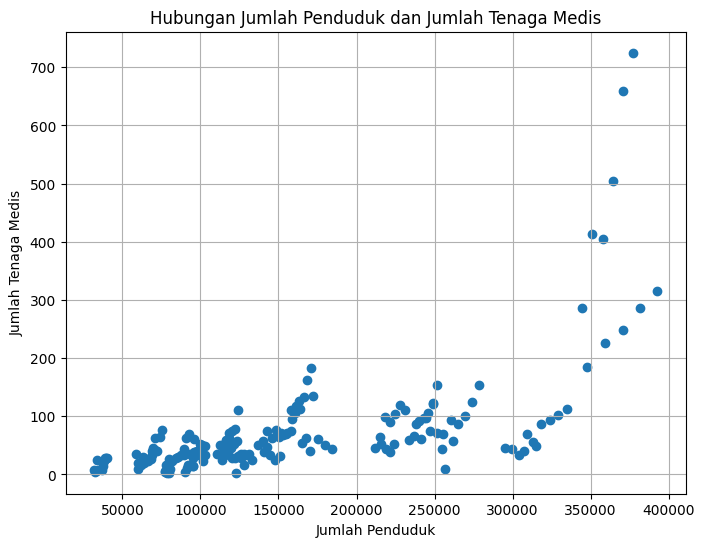

In [13]:
# ============================================================
# Melihat hubungan antara jumlah penduduk dan tenaga medis
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Jumlah_Penduduk"],
    df["Jumlah_Tenaga_Medis"]
)

plt.title("Hubungan Jumlah Penduduk dan Jumlah Tenaga Medis")
plt.xlabel("Jumlah Penduduk")
plt.ylabel("Jumlah Tenaga Medis")

plt.grid(True)
plt.show()

In [14]:
# ============================================================
# Mengukur hubungan antara jumlah penduduk dan tenaga medis
# ============================================================

korelasi = df[
    ["Jumlah_Penduduk", "Jumlah_Tenaga_Medis"]
].corr()

display(korelasi)

,Jumlah_Penduduk,Jumlah_Tenaga_Medis
Jumlah_Penduduk,1.000000,0.652709
Jumlah_Tenaga_Medis,0.652709,1.000000


In [15]:
# ============================================================
# Menghitung rasio tenaga medis per 1.000 penduduk
# ============================================================

df["Rasio_Tenaga_Medis"] = (
    df["Jumlah_Tenaga_Medis"] /
    df["Jumlah_Penduduk"]
) * 1000

display(
    df[
        [
            "Kabupaten_Kota",
            "Tahun",
            "Jumlah_Penduduk",
            "Jumlah_Tenaga_Medis",
            "Rasio_Tenaga_Medis"
        ]
    ].head(10)
)

,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Rasio_Tenaga_Medis
0,Baubau,2015,154877,69,0.445515
1,Baubau,2016,158271,110,0.695010
2,Baubau,2017,162780,112,0.688045
3,Baubau,2018,167519,63,0.376077
4,Baubau,2019,171802,135,0.785788
5,Baubau,2020,158820,95,0.598161
6,Baubau,2021,161280,118,0.731647
7,Baubau,2022,163720,113,0.690203
8,Baubau,2023,166150,133,0.800481
9,Baubau,2024,168500,162,0.961424


In [16]:
# ============================================================
# Menghitung kebutuhan tenaga medis berdasarkan standar
# 0,8 tenaga medis untuk setiap 1.000 penduduk
# ============================================================

STANDAR_KEMENKES = 0.8

df["Kebutuhan_Standar"] = (
    df["Jumlah_Penduduk"] / 1000
) * STANDAR_KEMENKES

display(
    df[
        [
            "Kabupaten_Kota",
            "Tahun",
            "Jumlah_Penduduk",
            "Jumlah_Tenaga_Medis",
            "Kebutuhan_Standar"
        ]
    ].head(10)
)

,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Kebutuhan_Standar
0,Baubau,2015,154877,69,123.9016
1,Baubau,2016,158271,110,126.6168
2,Baubau,2017,162780,112,130.2240
3,Baubau,2018,167519,63,134.0152
4,Baubau,2019,171802,135,137.4416
5,Baubau,2020,158820,95,127.0560
6,Baubau,2021,161280,118,129.0240
7,Baubau,2022,163720,113,130.9760
8,Baubau,2023,166150,133,132.9200
9,Baubau,2024,168500,162,134.8000


In [17]:
# ============================================================
# Menghitung selisih antara tenaga medis aktual
# dengan kebutuhan berdasarkan standar
# ============================================================

df["Selisih_Tenaga_Medis"] = (
    df["Jumlah_Tenaga_Medis"] -
    df["Kebutuhan_Standar"]
)

display(
    df[
        [
            "Kabupaten_Kota",
            "Tahun",
            "Jumlah_Tenaga_Medis",
            "Kebutuhan_Standar",
            "Selisih_Tenaga_Medis"
        ]
    ].head(10)
)

,Kabupaten_Kota,Tahun,Jumlah_Tenaga_Medis,Kebutuhan_Standar,Selisih_Tenaga_Medis
0,Baubau,2015,69,123.9016,-54.9016
1,Baubau,2016,110,126.6168,-16.6168
2,Baubau,2017,112,130.2240,-18.2240
3,Baubau,2018,63,134.0152,-71.0152
4,Baubau,2019,135,137.4416,-2.4416
5,Baubau,2020,95,127.0560,-32.0560
6,Baubau,2021,118,129.0240,-11.0240
7,Baubau,2022,113,130.9760,-17.9760
8,Baubau,2023,133,132.9200,0.0800
9,Baubau,2024,162,134.8000,27.2000


In [18]:
# ============================================================
# Menentukan status pemenuhan standar
# ============================================================

df["Status_Standar"] = df["Rasio_Tenaga_Medis"].apply(
    lambda x: "Memenuhi" if x >= STANDAR_KEMENKES
    else "Belum Memenuhi"
)

display(
    df[
        [
            "Kabupaten_Kota",
            "Tahun",
            "Rasio_Tenaga_Medis",
            "Status_Standar"
        ]
    ].head(10)
)

,Kabupaten_Kota,Tahun,Rasio_Tenaga_Medis,Status_Standar
0,Baubau,2015,0.445515,Belum Memenuhi
1,Baubau,2016,0.695010,Belum Memenuhi
2,Baubau,2017,0.688045,Belum Memenuhi
3,Baubau,2018,0.376077,Belum Memenuhi
4,Baubau,2019,0.785788,Belum Memenuhi
5,Baubau,2020,0.598161,Belum Memenuhi
6,Baubau,2021,0.731647,Belum Memenuhi
7,Baubau,2022,0.690203,Belum Memenuhi
8,Baubau,2023,0.800481,Memenuhi
9,Baubau,2024,0.961424,Memenuhi


In [19]:
# ============================================================
# Melihat seluruh informasi hasil analisis Tahap 3
# ============================================================

display(
    df[
        [
            "Kabupaten_Kota",
            "Tahun",
            "Jumlah_Penduduk",
            "Jumlah_Tenaga_Medis",
            "Rasio_Tenaga_Medis",
            "Kebutuhan_Standar",
            "Selisih_Tenaga_Medis",
            "Status_Standar"
        ]
    ].head(10)
)

,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Rasio_Tenaga_Medis,Kebutuhan_Standar,Selisih_Tenaga_Medis,Status_Standar
0,Baubau,2015,154877,69,0.445515,123.9016,-54.9016,Belum Memenuhi
1,Baubau,2016,158271,110,0.695010,126.6168,-16.6168,Belum Memenuhi
2,Baubau,2017,162780,112,0.688045,130.2240,-18.2240,Belum Memenuhi
3,Baubau,2018,167519,63,0.376077,134.0152,-71.0152,Belum Memenuhi
4,Baubau,2019,171802,135,0.785788,137.4416,-2.4416,Belum Memenuhi
5,Baubau,2020,158820,95,0.598161,127.0560,-32.0560,Belum Memenuhi
6,Baubau,2021,161280,118,0.731647,129.0240,-11.0240,Belum Memenuhi
7,Baubau,2022,163720,113,0.690203,130.9760,-17.9760,Belum Memenuhi
8,Baubau,2023,166150,133,0.800481,132.9200,0.0800,Memenuhi
9,Baubau,2024,168500,162,0.961424,134.8000,27.2000,Memenuhi


In [20]:
# ============================================================
# TAHAP 4 — FEATURE SELECTION
# Menentukan input dan target AI
# AI mempelajari pola jumlah tenaga medis aktual
# ============================================================

X = df[
    [
        "Jumlah_Penduduk",
        "Tahun",
        "Kabupaten_Kota"
    ]
].copy()

# Target AI = jumlah tenaga medis aktual
y = df["Jumlah_Tenaga_Medis"].copy()

print("Feature (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

Feature (X):
['Jumlah_Penduduk', 'Tahun', 'Kabupaten_Kota']

Target (y):
Jumlah_Tenaga_Medis


In [21]:
# ============================================================
# Mengubah data Kabupaten/Kota dari teks menjadi angka
# agar dapat digunakan oleh model machine learning
# ============================================================

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

wilayah_encoded = encoder.fit_transform(
    X[["Kabupaten_Kota"]]
)

print("Jumlah kolom hasil encoding:", wilayah_encoded.shape[1])

Jumlah kolom hasil encoding: 17


In [22]:
# ============================================================
# Menggabungkan jumlah penduduk, tahun,
# dan hasil encoding Kabupaten/Kota menjadi feature final
# ============================================================

import numpy as np

X_numerik = X[
    ["Jumlah_Penduduk", "Tahun"]
].to_numpy()

X_final = np.hstack([
    X_numerik,
    wilayah_encoded
])

print("Bentuk X final:", X_final.shape)
print("Bentuk y:", y.shape)

Bentuk X final: (187, 19)
Bentuk y: (187,)


In [23]:
# ============================================================
# TAHAP 5 — TRAIN-TEST SPLIT
# 2015–2024 = training
# 2025      = testing
# ============================================================

train_mask = df["Tahun"] < 2025
test_mask = df["Tahun"] == 2025

X_train = X_final[train_mask.to_numpy()]
X_test = X_final[test_mask.to_numpy()]

y_train = y[train_mask]
y_test = y[test_mask]

print("Jumlah data training :", len(X_train))
print("Jumlah data testing  :", len(X_test))

Jumlah data training : 170
Jumlah data testing  : 17


In [24]:
# ============================================================
# Memastikan tahun training dan testing sudah benar
# ============================================================

print("Tahun training :", sorted(df.loc[train_mask, "Tahun"].unique()))
print("Tahun testing  :", sorted(df.loc[test_mask, "Tahun"].unique()))

Tahun training : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Tahun testing  : [np.int64(2025)]


In [25]:
# ============================================================
# TAHAP 6 — PEMODELAN
# Mengimpor dua algoritma regresi yang akan dibandingkan
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [26]:
# ============================================================
# MODEL 1 — LINEAR REGRESSION
# Mempelajari pola jumlah tenaga medis dari data historis
# ============================================================

model_linear = LinearRegression()

model_linear.fit(X_train, y_train)

print("Linear Regression berhasil dilatih.")

Linear Regression berhasil dilatih.


In [27]:
# ============================================================
# MODEL 2 — RANDOM FOREST REGRESSION
# Mempelajari pola jumlah tenaga medis dari data historis
# ============================================================

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

print("Random Forest Regression berhasil dilatih.")

Random Forest Regression berhasil dilatih.


In [28]:
# ============================================================
# Memastikan kedua model sudah berhasil dibuat dan dilatih
# ============================================================

print("Model yang digunakan:")
print("1. Linear Regression")
print("2. Random Forest Regression")

print("\nJumlah data training:", len(X_train))
print("Jumlah target training:", len(y_train))

Model yang digunakan:
1. Linear Regression
2. Random Forest Regression

Jumlah data training: 170
Jumlah target training: 170


In [29]:
# ============================================================
# TAHAP 7 — EVALUASI MODEL
# Memprediksi jumlah tenaga medis tahun 2025
# ============================================================

y_pred_linear = model_linear.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

print("Prediksi Linear Regression berhasil dibuat.")
print("Prediksi Random Forest berhasil dibuat.")

Prediksi Linear Regression berhasil dibuat.
Prediksi Random Forest berhasil dibuat.


In [30]:
# ============================================================
# Menghitung MAE, RMSE, dan R² untuk kedua model
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluasi Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Evaluasi Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== LINEAR REGRESSION ===")
print("MAE  :", mae_linear)
print("RMSE :", rmse_linear)
print("R²   :", r2_linear)

print("\n=== RANDOM FOREST ===")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

=== LINEAR REGRESSION ===
MAE  : 37.73875535931588
RMSE : 83.90715385333601
R²   : 0.7085949530148246

=== RANDOM FOREST ===
MAE  : 25.376470588235293
RMSE : 42.49859776233453
R²   : 0.925243615202088


In [31]:
# ============================================================
# Membuat tabel perbandingan performa kedua model
# ============================================================

hasil_evaluasi = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

display(hasil_evaluasi)

,Model,MAE,RMSE,R2
0,Linear Regression,37.738755,83.907154,0.708595
1,Random Forest,25.376471,42.498598,0.925244


In [32]:
# ============================================================
# HASIL PREDIKSI DAN ANALISIS KEBUTUHAN TENAGA MEDIS
# ============================================================

hasil_prediksi = df.loc[
    test_mask,
    [
        "Kabupaten_Kota",
        "Tahun",
        "Jumlah_Penduduk",
        "Jumlah_Tenaga_Medis",
        "Kebutuhan_Standar"
    ]
].copy()

# Hasil prediksi dari AI
hasil_prediksi["Prediksi_Linear"] = y_pred_linear
hasil_prediksi["Prediksi_Random_Forest"] = y_pred_rf

# Menghitung jumlah tenaga medis yang masih kurang
hasil_prediksi["Kekurangan_Tenaga_Medis"] = (
    hasil_prediksi["Kebutuhan_Standar"]
    - hasil_prediksi["Jumlah_Tenaga_Medis"]
).clip(lower=0)

display(hasil_prediksi)

,Kabupaten_Kota,Tahun,Jumlah_Penduduk,Jumlah_Tenaga_Medis,Kebutuhan_Standar,Prediksi_Linear,Prediksi_Random_Forest,Kekurangan_Tenaga_Medis
10,Baubau,2025,170900,183,136.72,151.076039,148.34,0.00
21,Bombana,2025,163200,126,130.56,107.348234,103.09,4.56
32,Buton,2025,123900,111,99.12,88.393747,73.14,0.00
43,Buton Selatan,2025,102800,49,82.24,66.603274,51.09,33.24
54,Buton Tengah,2025,123100,57,98.48,64.712844,55.00,41.48
65,Buton Utara,2025,70600,62,56.48,68.016628,46.81,0.00
76,Kendari,2025,377300,725,301.84,390.729961,575.11,0.00
87,Kolaka,2025,251500,154,201.20,117.115022,116.61,47.20
98,Kolaka Timur,2025,129300,33,103.44,68.526665,37.47,70.44
109,Kolaka Utara,2025,151400,72,121.12,89.851728,76.32,49.12
